DATA SET CLEAN


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
dataset=pd.read_csv("dataset.csv", index_col=0)
outcome=pd.read_csv("outcome.csv", index_col=0)

In [3]:
#sets zusammenfügen
combined=dataset.join(outcome)

In [12]:
combined.shape

(1218, 16384)

In [4]:
combined.head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909,NaN
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,0.3459,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206,Her2
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,4.3645,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699,LumA
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,5.0536,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611,LumA
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,3.8982,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455,LumB
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,...,4.6815,7.8086,11.0203,0.0000,10.2189,3.5172,0.0000,2.6380,5.1659,LumB
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,...,5.2575,7.8006,9.9458,6.4553,9.8517,5.1557,0.3340,3.5460,5.1129,LumB
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,4.2091,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,1.4733,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,1.6536,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812,NaN


In [5]:
#Patienten mit fehlenden Werten anzeigen:
combined[combined.isna().sum(axis=1) > 0]

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909,NaN
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,4.2091,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,1.4733,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,1.6536,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812,NaN
TCGA-GM-A3XG-01,10.2287,5.3420,0.0000,11.8971,11.3988,10.3007,12.7280,4.5791,0.0000,5.2659,...,3.9286,6.5810,11.0255,0.0000,10.7494,3.7165,3.7165,3.8613,5.4490,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-C8-A8HP-01,10.1826,2.2159,0.0000,12.2653,11.4117,10.1413,12.6667,5.0266,0.0000,4.3536,...,4.6263,8.3054,11.2386,5.1052,10.4384,4.2652,0.0000,4.7617,4.6263,NaN
TCGA-E9-A5FL-01,9.9199,3.8645,3.7305,12.4815,10.4902,10.1415,12.3656,5.4259,0.0000,4.9709,...,7.3950,8.2324,12.1156,8.2781,9.5390,4.3026,0.7190,3.7991,4.2546,NaN
TCGA-E2-A15F-01,10.0334,0.8836,0.0000,12.0135,10.8370,10.5614,13.2703,3.1052,0.0000,5.7835,...,3.4777,7.3987,10.2279,0.0000,10.6019,3.6815,3.7735,1.4277,5.2548,NaN
TCGA-A2-A3XT-01,11.5144,1.3169,1.1329,11.5818,10.2736,9.9443,12.2951,3.8797,1.8814,6.7073,...,2.5291,8.5803,10.2809,0.0000,10.0345,4.4902,0.0000,4.0189,5.9153,NaN


In [7]:
#wie viele werte fehlen in diesem Dataset
combined.isna().sum(axis=1).sum()

np.int64(275)

In [ ]:
#wie viele Werte fehlen wo
combined.isna().sum(axis=0).sort_values(ascending=False)

BRCA_subtype    262
FGFR1OP2          5
RNF13             4
ATRX              4
PLIN3             0
               ... 
C16orf11          0
PLIN5             0
TSKS              0
IGFN1             0
PMM2              0
Length: 16384, dtype: int64

In [14]:
#alle Subtypen mit Nan entfernen 
combined_clean=combined.dropna(subset=["BRCA_subtype"])

In [15]:
#kontrolle wie viele noch übrig nachdem zeilen Subtyp=nan noch übrig
remaining_nans = combined_clean.isna().sum()

In [16]:
print(remaining_nans[remaining_nans > 0])

RNF13       2
FGFR1OP2    2
ATRX        2
dtype: int64


In [17]:
# Entferne die restlichen NaNs
combined_clean = combined_clean.dropna()

In [18]:
print(combined_clean.head(10))

                 ARHGEF10L   HIF3A   RNF17    RNF10    RNF11    RNF13  \
TCGA-D8-A1JA-01     7.4346  3.6607  0.6245  11.9181  13.5273  10.8702   
TCGA-BH-A0BQ-01     9.3216  2.7224  0.5526  11.9665  11.4105  10.4406   
TCGA-BH-A0BT-01     9.0198  1.3414  0.0000  13.1881  11.0911  10.4244   
TCGA-A8-A06X-01     9.6417  0.5819  0.0000  12.0036  11.2545  10.1480   
TCGA-A8-A096-01     9.7665  0.2738  0.8765  11.8118  10.8554  10.4282   
TCGA-BH-A0C7-01    10.0931  3.6090  0.0000  11.3820  10.7663  10.3366   
TCGA-AR-A0TV-01     9.6694  0.4330  0.0000  11.9378  11.2889  10.6282   
TCGA-BH-A18J-01     9.2718  2.1682  0.4324  12.3127  11.2739   9.9904   
TCGA-BH-A0W7-01     9.5610  2.6648  0.0000  11.9861  10.8410  10.0474   
TCGA-BH-A0HA-01     9.8078  1.9196  0.0000  12.4059  11.4196  10.4422   

                 GTF2IP1    REM1   MTVR2  RTN4RL2  ...     WT1   RNF24  \
TCGA-D8-A1JA-01  12.3048  2.5547  0.0000   6.0854  ...  0.3459  9.9935   
TCGA-BH-A0BQ-01  12.8186  4.7115  0.0000   5.832

In [19]:
combined_clean.shape

(950, 16384)

In [20]:
#kontrolle ob alle Nans weg
print(combined_clean.isna().sum().sum())

0


IMBALANCE BEWEISEN

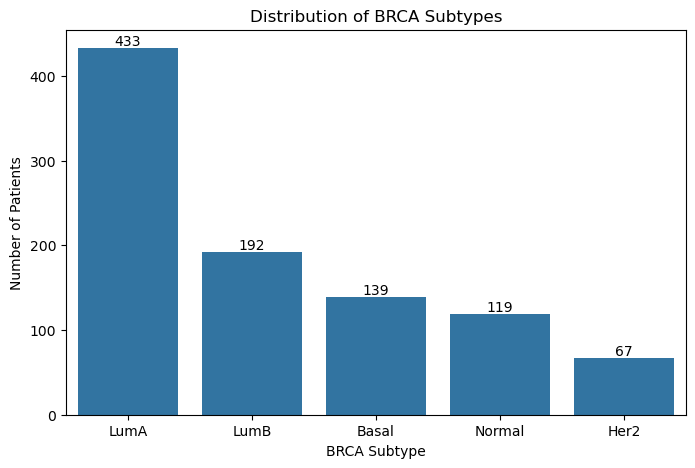

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=combined_clean, #weil die patienten ohne NaN nichts aussagen
    x="BRCA_subtype",
    order=combined_clean["BRCA_subtype"].value_counts().index
)

# Zahlen über Balken schreiben
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of BRCA Subtypes")
plt.xlabel("BRCA Subtype")
plt.ylabel("Number of Patients")

plt.show()

VARIANZEN PRÜFEN

In [25]:
# Features und Label trennen
X = combined_clean.drop(columns=["BRCA_subtype"])
y = combined_clean["BRCA_subtype"]

In [33]:
print(X.shape)

(950, 16383)


In [26]:
# Varianz jedes Gens berechnen
variances = X.var()

In [31]:
# Statistische Übersicht
print(variances.describe())

count    16383.000000
mean         1.239637
std          1.742989
min          0.000000
25%          0.279232
50%          0.595600
75%          1.528650
max         37.376686
dtype: float64


| Statistik       | Bedeutung                                       |
| --------------- | ----------------------------------------------- |
| `count = 16383` | so viele Gene/Fatures habt ihr                  |
| `min = 0`       | mindestens ein Gen hat exakt keine Varianz      |
| `25% = 0.279`   | 25 % aller Gene haben Varianz kleiner als 0.279 |
| `50% = 0.596`   | Medianvarianz                                   |
| `75% = 1.529`   | obere 25 % sind deutlich variabler              |
| `max = 37.37`   | einige Gene variieren extrem stark              |


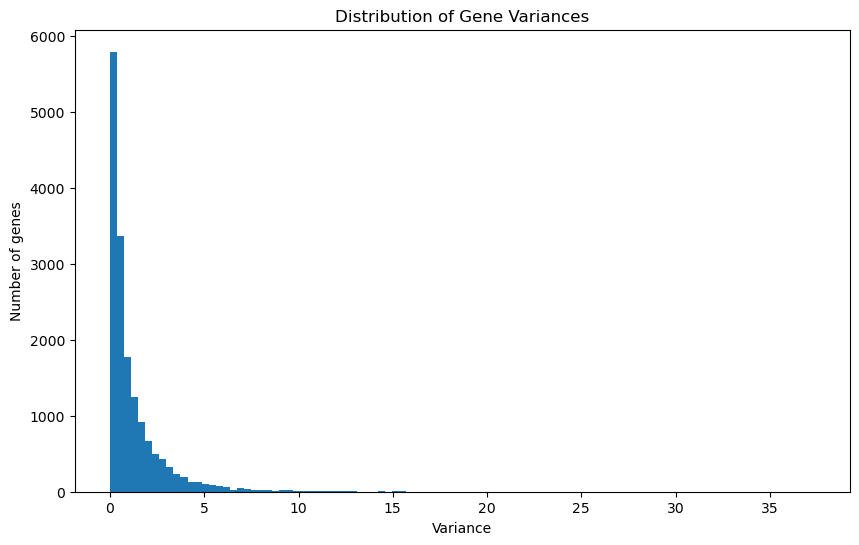

In [30]:
# Histogramm der Varianzen
plt.figure(figsize=(10,6))
plt.hist(variances, bins=100)

plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of Gene Variances")

plt.show()

In [34]:
overview = pd.DataFrame({
    "variable": combined_clean.columns,
    "dtype": combined_clean.dtypes.astype(str).values,
    "n_unique": [combined_clean[col].nunique() for col in combined_clean.columns]
})

display(overview)

,variable,dtype,n_unique
0,ARHGEF10L,float64,931
1,HIF3A,float64,911
2,RNF17,float64,219
3,RNF10,float64,906
4,RNF11,float64,925
...,...,...,...
16379,HCG27,float64,934
16380,CYP2A13,float64,342
16381,CCR10,float64,937
16382,KDM4D,float64,932


In [35]:
overview.head() #ersten 5 Zeilen
#n_unique: fast jeder Patient hat leicht anderen Wert
#normales Verhalten für RNA Seq

,variable,dtype,n_unique
0,ARHGEF10L,float64,931
1,HIF3A,float64,911
2,RNF17,float64,219
3,RNF10,float64,906
4,RNF11,float64,925


In [36]:
#Sortiert dataFrame nach ANzahl untershciedlicher Werte, aufsteigend
overview.sort_values("n_unique")
#n_unique=1: dises Gen hat bei allen Patienten exact denselben wert --> Keine hilfreiche Info

,variable,dtype,n_unique
12822,SNORD116-11,int64,1
12820,SNORA35,int64,1
7440,SNORD27,int64,1
13746,SNORD114-16,int64,1
15538,SNORD114-15,int64,1
...,...,...,...
10406,ST6GALNAC3,float64,949
1466,FSIP1,float64,949
3728,AGAP11,float64,949
13090,LTF,float64,949


In [37]:
#Auf low variance prüfen 
overview.sort_values("n_unique").head(20)

,variable,dtype,n_unique
12822,SNORD116-11,int64,1
12820,SNORA35,int64,1
7440,SNORD27,int64,1
13746,SNORD114-16,int64,1
15538,SNORD114-15,int64,1
1743,SNORD113-7,int64,1
15350,SNORD92,int64,1
2031,SNORD4B,int64,1
15304,SNORD90,int64,1
732,SNORD38A,int64,1


In [38]:
#Standardabweichung / Varianz prüfen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()
#.std(): Berechnet std : Wie stark streuuen die Werte um den Mittelwert
gene_std.sort_values().head(20)

#Output=0: überhaupt keine Streuung

SNORD113-4     0.0
TXNDC8         0.0
RBMY1A3P       0.0
SNORD88B       0.0
TTTY3B         0.0
SNORD115-2     0.0
SNORD115-3     0.0
SNORD116-13    0.0
TTTY6B         0.0
DAZ4           0.0
SNORD60        0.0
SNORD115-11    0.0
SNORD44        0.0
TSSK2          0.0
LOC653545      0.0
SNORD105       0.0
SNORD91A       0.0
SNAR-D         0.0
SNORA11C       0.0
SNORD115-16    0.0
dtype: float64

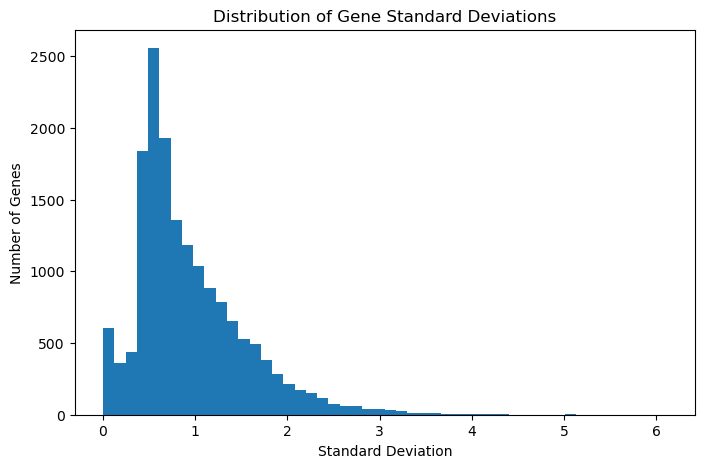

In [39]:
#Histogramm der Standardabweichungen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()

plt.figure(figsize=(8,5))
plt.hist(gene_std, bins=50)
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Standard Deviations")
plt.show()

In [40]:
#Um alle Gene mit n_unique = 1 zu sehen (also konstante Features), filterst du einfach dein overview-DataFrame:
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [41]:
# nur die Namen der Gene 
constant_gene_names = constant_features["variable"].tolist()

print(constant_gene_names)

['RBMY1A3P', 'SNORD115-17', 'SNORD114-31', 'SNORD114-30', 'SNORD115-6', 'SNORD115-4', 'SNORD104', 'SNORD115-9', 'SNORD38A', 'KRTAP19-7', 'KRTAP19-4', 'SNORD114-3', 'HBII-52-27', 'SNORD11', 'SNORD12', 'SNORD21', 'SNORD20', 'SNORD25', 'SNORD127', 'DAZ3', 'DAZ2', 'DAZ4', 'SNORD124', 'TTTY17A', 'SNORD115-5', 'SNORD80', 'SNORD56B', 'SNORD78', 'SNORD113-7', 'SNORD96A', 'SNORD119', 'HBII-52-46', 'HBII-52-45', 'SNORD47', 'SNORD4B', 'SNORD4A', 'SNORD116-24', 'SNORD116-25', 'SNORD116-23', 'SNORD116-29', 'RBMY1B', 'RBMY1F', 'BPY2', 'SNORD115-8', 'SNORD66', 'HBII-52-28', 'SNORD69', 'SNORD68', 'SNORD38B', 'SNORD113-4', 'SNORD116-26', 'SNORD115-1', 'SNORD58A', 'SNORD58C', 'PRR20A', 'PRR20D', 'SNORD96B', 'SNORD63', 'SNORD116-22', 'SNORD81', 'PLA2G2E', 'PRAMEF3', 'SNORD114-20', 'SNAR-A3', 'SNORD115-20', 'SNORD115-22', 'SNORD115-25', 'SNORD114-29', 'TEX28', 'CEACAM18', 'SNORD29', 'S100A7L2', 'LOC653545', 'SNORD16', 'SNORD36A', 'SNORD91B', 'SNORD87', 'SNORD86', 'DEFB116', 'DEFB114', 'DEFB112', 'TTTY4C',

In [42]:
#anzahl der gene
print(len(constant_gene_names))
print(f"{len(constant_gene_names)} constant genes found.")

221
221 constant genes found.


In [44]:
#ohne konstante gene
constant_genes = gene_std[gene_std == 0].index #filtern alle gene mit std=0, index nnimmt nur deren Namen

combined_no_constant = combined_clean.drop(columns=constant_genes)

In [45]:
print(combined_clean.shape)
print(combined_no_constant.shape)

(950, 16384)
(950, 16163)


In [48]:
#prüfen ob keine konstanten features mehr vorhanden
combined_no_constant.drop(columns="BRCA_subtype").std().min()

np.float64(0.00853284675147811)

In [50]:
#finaler Analyse Datensatz
analysis = combined_no_constant.copy()

SAMPLING VERGLEICHE

In [65]:
target = "BRCA_subtype"
sample_frac = 0.2
n_repeats = 500

#normalize = True: wandelt absolute count in relative Häufigkeiten/ Anteile um
#Proportion=Anzahl Subtyp​/Gesamtzahl Patienten
#sort_index: sortiert alphabetisch nach labelnamen
original_props = analysis[target].value_counts(normalize=True).sort_index()
original_props

#Output: Propotinalen Anteile jedes Subtypens im gesamten Datensatz

BRCA_subtype
Basal     0.146316
Her2      0.070526
LumA      0.455789
LumB      0.202105
Normal    0.125263
Name: proportion, dtype: float64

In [64]:
#Simple Random Sampling mehrfach testen 
#misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
simple_errors = []

for i in range(n_repeats):
    sample = analysis.sample(frac=sample_frac, random_state=i)
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    #berechnet die Subtypen Proportionen des Samples
    error = (sample_props - original_props).abs().sum() #Wie stark weicht jede Klasse ab, abs. = absoluter wert
    simple_errors.append(error)

simple_mean_error = np.mean(simple_errors)# durchschnittliccher Sampling-Fehler
simple_mean_error

#Output: Im Durchschnitt weicht ein einfach zufällig gezogenes Sample 
# um etwa 9.5 Prozentpunkte Gesamtverteilung von der 
# ursprünglichen Subtyp-Verteilung ab.

np.float64(0.0950778947368421)

In [63]:
#stratefied sampling mehrfach testen
##misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
strat_errors = []

for i in range(n_repeats):
    sample = (
        analysis
        .groupby(target, group_keys=False)
        .sample(frac=sample_frac, random_state=i)
    )
    
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    error = (sample_props - original_props).abs().sum()
    strat_errors.append(error)

strat_mean_error = np.mean(strat_errors)
strat_mean_error

#Output: Die Verteilung eines stratified samples weicht 
# im Durchschnitt nur um 0.79 Prozentpunkte Gesamtverteilung 
# vom Originaldatensatz ab.

np.float64(0.008421052631578899)

In [55]:
#Vergleiche anzeigen
comparison = pd.DataFrame({
    "method": ["Simple random sampling", "Stratified sampling"],
    "mean_distribution_error": [simple_mean_error, strat_mean_error]
})

display(comparison)

#Stratified sampling erhält die ursprüngliche Subtyp-Verteilung besser.

,method,mean_distribution_error
0,Simple random sampling,0.095078
1,Stratified sampling,0.008421


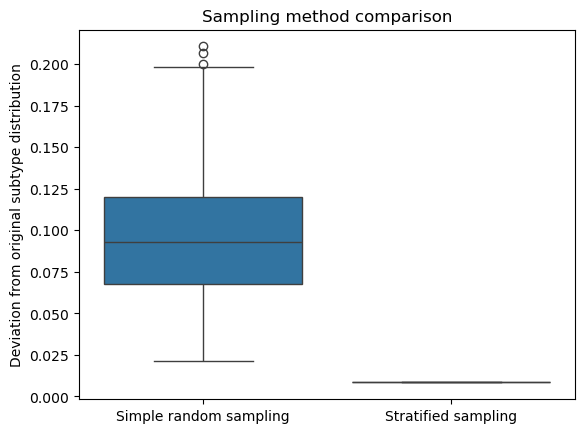

In [56]:
#visuell darstelle

error_df = pd.DataFrame({
    "Simple random sampling": simple_errors,
    "Stratified sampling": strat_errors
})

sns.boxplot(data=error_df)
plt.ylabel("Deviation from original subtype distribution")
plt.title("Sampling method comparison")
plt.show()

Der Vergleich zeigt, dass Stratified Sampling die ursprüngliche Verteilung der BRCA-Subtypen deutlich besser erhält als Simple Random Sampling. Beim Simple Random Sampling schwankt die Klassenverteilung stärker, wodurch einzelne Subtypen im Sample über- oder unterrepräsentiert sein können. Stratified Sampling zieht dagegen proportional gleich viele Patienten aus jedem Subtyp und erzeugt dadurch stabilere und repräsentativere Samples. Deshalb eignet sich Stratified Sampling besser für unser Klassifikationsproblem

Test/Train Split weil sonst leakage

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
# Features und Labels
X = combined_no_constant.drop(columns=["BRCA_subtype"])
y = combined_no_constant["BRCA_subtype"]

In [ ]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #sorgt für rpoduzierbarkeit
    stratify=y #sampling art
)
#20 % test daten
#80% trainingsdaten

In [60]:
# Shapes kontrollieren
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (760, 16162)
X_test: (190, 16162)
y_train: (760,)
y_test: (190,)


In [ ]:
#ob die Verteilungen ähnlich geblieben ist
print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

BRCA_subtype
LumA      0.455789
LumB      0.202105
Basal     0.146316
Normal    0.125263
Her2      0.070526
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.455263
LumB      0.202632
Basal     0.146053
Normal    0.125000
Her2      0.071053
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.457895
LumB      0.200000
Basal     0.147368
Normal    0.126316
Her2      0.068421
Name: proportion, dtype: float64


| Subtyp | Gesamt | Train  | Test   |
| ------ | ------ | ------ | ------ |
| LumA   | 45.6 % | 45.5 % | 45.8 % |
| Her2   | 7.1 %  | 7.1 %  | 6.8 %  |


ANOVA F-test

In [ ]:
#welche Gene unterscheiden die Subtypen am stärksten
